# Constraint automaton → $A_q$ → Grover / QAOA: a small hardware-ready example

**Author:** Alberto Maldonado Romo (QOSF) · part of the `negsearch` repository (paper, Section 7).

**Idea.** For *any* constraint set $F\subseteq\{0,1\}^n$ there is a minimal **constraint automaton**. Reading the variables in order, a value that cannot be completed to a feasible string is *forbidden* (a negative condition); otherwise the variable is a coin $R_Y(\theta_q)$. The resulting state $A_q|0\rangle=\sum_{x\in F}\sqrt{\mu_q(x)}\,|x\rangle|g(x)\rangle$ is supported **exactly on $F$**. It can be used

* as the starting point of **amplitude amplification** (Grover): at most as many iterations as Grover on $|+\rangle^{\otimes n}$, and the oracle only tests the objective, never feasibility;
* as the initial state of **QAOA** with a Grover mixer (any constraint) or a structure-preserving mixer: every sample is feasible by construction, no penalty weight, no slack qubits.

**What this notebook does.** It takes a tiny exact-cover instance (6 sets, 4 elements, 6 decision qubits) and

1. builds the automaton and the circuit $A_q$ with the generic compiler,
2. checks the circuit against the exact distribution,
3. predicts what `ibm_fez` should return (noise model),
4. runs on real hardware if you set `RUN_HARDWARE = True` (your own IBM Quantum key, never committed),
5. compares hardware, noise model and ideal.

**What it does not claim.** There is no quantum advantage here: the instance is solved by inspection, and amplitude amplification gives only a quadratic gain over classical sampling from the same $A_q$. The point is a runnable, honest test of *feasibility-by-construction* on a real device.

In [1]:
import sys, json, math, time, os
sys.path.insert(0, '..')
import numpy as np, matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from negsearch.automaton import (build_automaton, compile_Aq, mu_q, best_k, grover_curve, grover_iteration_circuit,
                                 from_qiskit)
from negsearch import families as fam

## 1. The constraint problem

Exact cover: choose a sub-collection of the 6 sets so that **every** element is covered **exactly once**; minimise the total weight. `fam.exact_cover` builds the feasible set $F$ as an explicit truth table (fine for $n\le16$; larger instances write the automaton from the problem structure, see `negsearch/structural.py`). To try another constraint type change the cell below, e.g. `fam.set_packing(6, 5, 33)`, `fam.knapsack(6, 11)` (different weights), `fam.mis(6, 0.4, 22)` or `fam.colouring(3, 55, 0.7)`.

In [2]:
def pick_exact_cover():
    # the instance used in the paper's hardware example: 6 sets, 3 feasible covers, one optimum, a = 1/4
    for s in range(60):
        P = fam.exact_cover(6, 4, 100 + s)
        if P.nF < 3: continue
        A = build_automaton(P.feas, P.n); mu, _ = mu_q(A, 0.5); G = P.good(0.0)
        if abs(mu[G].sum() - 0.25) < 1e-9 and compile_Aq(A, 0.5)[0].num_qubits == 8:
            return P
P = pick_exact_cover(); n = P.n
A = build_automaton(P.feas, n); mu, D = mu_q(A, 0.5); G = P.good(0.0)
X = ((np.arange(2 ** n)[:, None] >> (n - 1 - np.arange(n))) & 1)
print(P.name, '| n =', n, '| feasible strings:', P.nF, 'of', 2 ** n, '| optimum cost:', P.opt)
for x in np.flatnonzero(P.feas):
    print('  x =', ''.join(map(str, X[x])), ' cost', P.cost[x], ' mu_q =', round(mu[x], 4), ' optimal' if G[x] else '')
print('automaton width per level:', A.width)
print(f'P(optimum): uniform state {G.sum() / 2**n:.4f}   |   A_q|0> {mu[G].sum():.4f}')

exact cover (6 sets, 4 elements) | n = 6 | feasible strings: 3 of 64 | optimum cost: 7.0
  x = 000101  cost 11.0  mu_q = 0.25 
  x = 001001  cost 7.0  mu_q = 0.25  optimal
  x = 010001  cost 9.0  mu_q = 0.5 
automaton width per level: [1, 1, 2, 2, 1, 1, 1]
P(optimum): uniform state 0.0156   |   A_q|0> 0.2500


## 2. The circuit $A_q$ and an exact check

The compiler turns each automaton state into a small binary register and each decision into a controlled $R_Y$; forced values become controlled $X$ gates. Nothing here is problem-specific.

In [3]:
Aq, info = compile_Aq(A, 0.5)
print('qubits:', Aq.num_qubits, '(', n, 'decisions +', Aq.num_qubits - n, 'automaton-register qubits )')
display_circ = Aq.decompose(reps=1)
print(Aq.draw(output='text', fold=140))

ideal = AerSimulator(method='statevector')
c = Aq.copy(); c.save_statevector()
sv = np.asarray(ideal.run(transpile(c, ideal, optimization_level=0)).result().get_statevector().data)
px = from_qiskit((np.abs(sv.reshape(-1, 2 ** n)) ** 2).sum(0), n)
print('max |circuit - exact mu_q| =', np.abs(px - mu).max(), '   mass on infeasible strings =', px[~P.feas].sum())

qubits: 8 ( 6 decisions + 2 automaton-register qubits )
                                               
q_0: ──────────────────────────────────────────
     ┌─────────┐                               
q_1: ┤ Ry(π/2) ├──■────────────────────────────
     └─────────┘  │  ┌─────────┐               
q_2: ─────────────┼──┤ Ry(π/2) ├──■────o───────
                  │  └────┬────┘  │    │  ┌───┐
q_3: ─────────────┼───────┼───────┼────┼──┤ X ├
                  │       │       │    │  └─┬─┘
q_4: ─────────────┼───────┼───────┼────┼────┼──
        ┌───┐     │       │       │    │    │  
q_5: ───┤ X ├─────┼───────┼───────┼────┼────┼──
        └───┘   ┌─┴─┐     │       │    │    │  
q_6: ───────────┤ X ├─────o───────o────■────┼──
                └───┘           ┌─┴─┐┌─┴─┐  │  
q_7: ───────────────────────────┤ X ├┤ X ├──o──
                                └───┘└───┘     


max |circuit - exact mu_q| = 1.1102230246251565e-16    mass on infeasible strings = 0.0


## 3. Two circuits for the experiment

* **A. $A_q$ alone** (24 CZ): measure the six decision qubits. Hardware noise lets some samples fall outside $F$; the **share of feasible samples** is a direct, honest fidelity test. Uniform sampling would give $|F|/2^n$.
* **B. One amplification iteration** on $A_q$: oracle marks the optimum, then the reflection about $A_q|0\rangle$ (here the reflection about $|0\ldots0\rangle$ uses a Toffoli V-chain). Ideal success probability goes from $1/4$ to $1$.

The objective-threshold oracle is a diagonal gate on the decision qubits; a standard Grover iteration would additionally need a feasibility check inside its oracle.

In [4]:
circB, NB = grover_iteration_circuit(A, G, vchain=True)
def with_meas(circ):
    c = QuantumCircuit(circ.num_qubits, n); c.compose(circ, inplace=True)
    for i in range(n): c.measure(i, i)
    return c
CIRCS = {'A_q alone': with_meas(Aq), '1 amplification iteration': with_meas(circB)}

# ideal check of B
c = circB.copy(); c.save_statevector()
sv = np.asarray(ideal.run(transpile(c, ideal, optimization_level=0)).result().get_statevector().data)
pB = from_qiskit((np.abs(sv.reshape(-1, 2 ** n)) ** 2).sum(0), n)
print(f'ideal P(optimum): A_q alone {mu[G].sum():.3f} -> after 1 iteration {pB[G].sum():.3f}')

ideal P(optimum): A_q alone 0.250 -> after 1 iteration 1.000


## 4. Cost on `ibm_fez` and noise-model prediction

`FakeFez` carries the calibration data and noise of `ibm_fez`. The numbers below are what we expect before using any real device time.

In [5]:
from qiskit_ibm_runtime.fake_provider import FakeFez
bk = FakeFez(); noisy = AerSimulator.from_backend(bk)
SHOTS = 4000

def decode(counts):
    # classical bit i = decision variable x_i; x_0 is the most significant bit of the index used by the problem arrays
    out = np.zeros(2 ** n)
    for k, v in counts.items():
        bits = [int(ch) for ch in k.replace(' ', '')[::-1]]
        out[int(''.join(map(str, bits)), 2)] += v
    return out / out.sum()

def summary(p):
    return dict(p_feasible=float(p[P.feas].sum()), p_optimum=float(p[G].sum()))

ISA = {k: transpile(c, bk, optimization_level=3, seed_transpiler=1) for k, c in CIRCS.items()}
PRED = {}
rows = []
for k, t in ISA.items():
    cnt = noisy.run(t, shots=SHOTS, seed_simulator=1).result().get_counts()
    PRED[k] = decode(cnt)
    rows.append((k, t.count_ops().get('cz', 0), t.depth(), *summary(PRED[k]).values()))
print(f"{'circuit':28s} {'CZ':>5s} {'depth':>6s}  P(feasible)  P(optimum)")
for r in rows: print(f"{r[0]:28s} {r[1]:5d} {r[2]:6d}  {r[3]:10.3f}  {r[4]:10.3f}")
print(f"{'reference: uniform state':28s} {'':5s} {'':6s}  {P.nF / 2**n:10.3f}  {G.sum() / 2**n:10.3f}")
print(f"{'reference: ideal A_q':28s} {'':5s} {'':6s}  {1.0:10.3f}  {mu[G].sum():10.3f}")
print(f"{'reference: ideal 1 iteration':28s} {'':5s} {'':6s}  {1.0:10.3f}  {pB[G].sum():10.3f}")

circuit                         CZ  depth  P(feasible)  P(optimum)
A_q alone                       24     81       0.893       0.209
1 amplification iteration      333    826       0.460       0.323
reference: uniform state                        0.047       0.016
reference: ideal A_q                            1.000       0.250
reference: ideal 1 iteration                    1.000       1.000


## 5. Run on hardware

Set `RUN_HARDWARE = True` and put your IBM Quantum API key in a JSON file `{"apikey": "..."}` that stays out of version control (`.gitignore` already excludes `apikey*.json`). The cell sends both circuits in one job with dynamical decoupling and gate twirling enabled, and stores the raw counts in `results/hardware_general_*.json`. The 333-CZ circuit is at the edge of what a current device can run meaningfully: expect the amplified circuit to lose most of its ideal advantage; the noise-model line above is the fair expectation.

In [6]:
RUN_HARDWARE = False
API_KEY_FILE = 'apikey_personal.json'     # JSON {"apikey": "..."}; NEVER commit it
BACKEND_NAME = 'ibm_fez'                  # falls back to the least busy device with >= 20 qubits
HW = None
if RUN_HARDWARE:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
    service = QiskitRuntimeService(channel='ibm_cloud', token=json.load(open(API_KEY_FILE))['apikey'])
    try:
        backend = service.backend(BACKEND_NAME)
    except Exception:
        backend = service.least_busy(operational=True, simulator=False, min_num_qubits=20)
    print('backend:', backend.name)
    isa = {k: transpile(c, backend, optimization_level=3, seed_transpiler=1) for k, c in CIRCS.items()}
    sampler = Sampler(mode=backend)
    sampler.options.dynamical_decoupling.enable = True
    sampler.options.twirling.enable_gates = True
    job = sampler.run(list(isa.values()), shots=8000)
    print('job_id:', job.job_id())
    res = job.result()
    HW = {k: dict(res[i].data.c.get_counts()) for i, k in enumerate(isa)}
    os.makedirs('../results', exist_ok=True)
    fn = f"../results/hardware_general_{backend.name}_{time.strftime('%Y%m%d_%H%M%S')}.json"
    json.dump(dict(backend=backend.name, job_id=job.job_id(), shots=8000, counts=HW,
                   cz={k: v.count_ops().get('cz', 0) for k, v in isa.items()}), open(fn, 'w'))
    print('saved', fn)
else:
    print('hardware run disabled (RUN_HARDWARE = False); showing the noise-model prediction only')

hardware run disabled (RUN_HARDWARE = False); showing the noise-model prediction only


## 6. Compare ideal, noise model and hardware

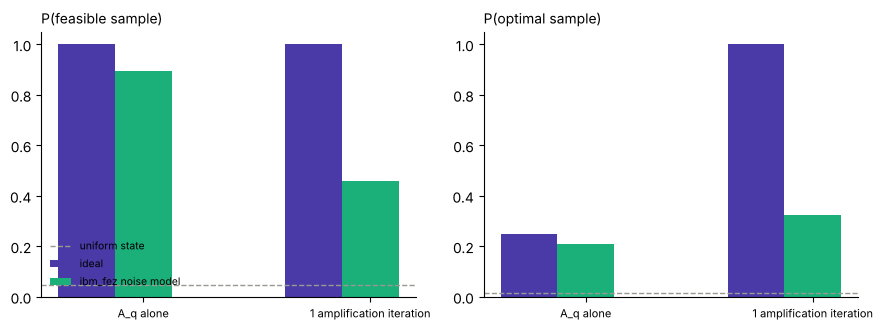

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(9, 3.4))
names = list(CIRCS)
for ax, key, title in zip(axs, ('p_feasible', 'p_optimum'), ('P(feasible sample)', 'P(optimal sample)')):
    ref = {'uniform': P.nF / 2 ** n if key == 'p_feasible' else G.sum() / 2 ** n}
    idealv = [1.0 if key == 'p_feasible' else mu[G].sum(), 1.0 if key == 'p_feasible' else pB[G].sum()]
    noisev = [summary(PRED[k])[key] for k in names]
    xs = np.arange(len(names)); w = 0.25
    ax.bar(xs - w, idealv, w, color='#4a3aa7', label='ideal')
    ax.bar(xs, noisev, w, color='#1baf7a', label='ibm_fez noise model')
    if HW is not None:
        hwv = [summary(decode(HW[k]))[key] for k in names]
        ax.bar(xs + w, hwv, w, color='#eb6834', label='hardware')
    ax.axhline(ref['uniform'], color='#9a9893', ls='--', lw=1, label='uniform state')
    ax.set_xticks(xs); ax.set_xticklabels(names, fontsize=8); ax.set_title(title, fontsize=10, loc='left'); ax.set_ylim(0, 1.05)
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
axs[0].legend(fontsize=7.5, frameon=False, loc='lower left')
plt.tight_layout(); plt.show()

## 7. Other constraint types, QAOA, and what is runnable today

* **Another constraint.** Replace `P` in section 1 by `fam.set_packing(6, 5, 33)` (97 CZ for $A_q$), `fam.knapsack(6, 11)` (297 CZ), `fam.mis(6, 0.4, 22)` or `fam.colouring(3, 55, 0.7)`; everything else is unchanged. The paper reports, for these seven families, the iteration savings, QAOA quality and compiler validation (`experiments/general_*.py`).
* **QAOA.** With the Grover mixer, $A_q$ gives 100 % feasible samples at every depth for *any* constraint, but each layer contains two copies of $A_q$ plus a reflection (hundreds to thousands of CZ here), which is a fault-tolerant design. For count constraints (portfolio, cardinality) the cheap route is the XY mixer with counts sampled classically and Dicke states on the chip: see `Portfolio_QOBLIB_constraint_guided_QAOA.ipynb` (24–40 CZ on 12 qubits).
* **Scale.** The same compiler runs on Aer's MPS simulator up to 80 decision variables / 274 qubits when the automaton is written from the structure (`experiments/general_scaling_mps.py`).
* **Honest summary.** Feasibility by construction and fewer amplification iterations are real; a quantum advantage over classical solvers is not claimed, and exact look-ahead is only cheap when the automaton width is small.